# Project Overview

### Jersey City Bikeshare

This project analyzes Jersey City bikeshare trip data to uncover ridership patterns, station usage trends, seasonal demand, and rider behavior. Using Python, data cleaning techniques, exploratory data analysis (EDA), feature engineering, and clustering, the analysis examines how and when bikes are used throughout the city.

Key objectives include:

1. Identifying peak ridership periods and seasonal trends
2. Determining the busiest start and end stations
3. Investigating station flow imbalances that may impact operations
4. Comparing rider characteristics and usage patterns
5. Segmenting riders into meaningful groups through cluster analysis


# Importing libraries and dataset

In [1]:
!pip install folium

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
import folium
from folium.plugins import MarkerCluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
file_path = "C:\\Users\\msche\\OneDrive\\Desktop\\Data_Projects\\NYC_Bikeshare\\NYC_BikeShare.xlsx"
df = pd.read_excel(file_path, sheet_name="NYC-BikeShare-2015-2017-combine")
df.head()

,ID_Number,Trip_Duration,Start_Time,Stop_Time,Start_Station_ID,Start_Station_Name,Start_Station_Latitude,Start_Station_Longitude,End_Station_ID,End_Station_Name,End_Station_Latitude,End_Station_Longitude,Bike_ID,User_Type,Birth_Year,Gender,Trip_Duration_in_min
0,0,376,2015-10-01 00:16:26,2015-10-01 00:22:42,3212,Christ Hospital,40.734786,-74.050444,3207,Oakland Ave,40.737604,-74.052478,24470,Subscriber,1960,1,6
1,1,739,2015-10-01 00:27:12,2015-10-01 00:39:32,3207,Oakland Ave,40.737604,-74.052478,3212,Christ Hospital,40.734786,-74.050444,24481,Subscriber,1960,1,12
2,2,2714,2015-10-01 00:32:46,2015-10-01 01:18:01,3193,Lincoln Park,40.724605,-74.078406,3193,Lincoln Park,40.724605,-74.078406,24628,Subscriber,1983,1,45
3,3,275,2015-10-01 00:34:31,2015-10-01 00:39:06,3199,Newport Pkwy,40.728745,-74.032108,3187,Warren St,40.721124,-74.038051,24613,Subscriber,1975,1,5
4,4,561,2015-10-01 00:40:12,2015-10-01 00:49:33,3183,Exchange Place,40.716247,-74.033459,3192,Liberty Light Rail,40.711242,-74.055701,24668,Customer,1984,0,9


# Data Cleaning

### Overview of the dataset

In [4]:
df.head()
df.tail()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735502 entries, 0 to 735501
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   ID_Number                735502 non-null  int64         
 1   Trip_Duration            735502 non-null  int64         
 2   Start_Time               735502 non-null  datetime64[ns]
 3   Stop_Time                735502 non-null  datetime64[ns]
 4   Start_Station_ID         735502 non-null  int64         
 5   Start_Station_Name       735502 non-null  object        
 6   Start_Station_Latitude   735502 non-null  float64       
 7   Start_Station_Longitude  735502 non-null  float64       
 8   End_Station_ID           735502 non-null  int64         
 9   End_Station_Name         735502 non-null  object        
 10  End_Station_Latitude     735502 non-null  float64       
 11  End_Station_Longitude    735502 non-null  float64       
 12  Bike_ID         

,ID_Number,Trip_Duration,Start_Time,Stop_Time,Start_Station_ID,Start_Station_Latitude,Start_Station_Longitude,End_Station_ID,End_Station_Latitude,End_Station_Longitude,Bike_ID,Birth_Year,Gender,Trip_Duration_in_min
count,735502.000000,7.355020e+05,735502,735502,735502.000000,735502.000000,735502.000000,735502.000000,735502.000000,735502.000000,735502.000000,735502.000000,735502.000000,735502.000000
mean,10582.401084,9.343125e+02,2016-07-07 12:47:13.509627648,2016-07-07 13:02:48.282860288,3206.764183,40.723125,-74.046412,3203.387325,40.722371,-74.045415,24914.009133,1979.544239,1.123668,15.570669
min,0.000000,6.100000e+01,2015-09-21 14:53:16,2015-09-21 14:54:17,3183.000000,40.692640,-74.096937,147.000000,0.000000,-74.096937,14552.000000,1900.000000,0.000000,1.000000
25%,4484.000000,2.460000e+02,2016-03-18 08:18:38.500000,2016-03-18 08:27:07,3186.000000,40.717732,-74.050656,3186.000000,40.716540,-74.050444,24486.000000,1975.000000,1.000000,4.000000
50%,9156.000000,3.830000e+02,2016-08-02 16:27:28,2016-08-02 16:46:03,3202.000000,40.721525,-74.044247,3199.000000,40.721124,-74.043845,24602.000000,1982.000000,1.000000,6.000000
75%,15003.000000,6.520000e+02,2016-10-27 04:09:40,2016-10-27 05:09:00,3211.000000,40.727596,-74.038051,3211.000000,40.727224,-74.036486,24711.000000,1986.000000,1.000000,11.000000
max,34148.000000,2.026021e+07,2017-03-31 23:25:34,2017-04-01 10:01:54,3426.000000,40.752559,-74.032108,3442.000000,40.801343,0.000000,29296.000000,2000.000000,2.000000,337670.000000
std,7679.871929,4.063878e+04,NaN,NaN,26.546683,0.008121,0.011191,64.358120,0.095296,0.173044,753.768581,9.371192,0.519694,677.312437


In [5]:
def dataset_overview(df):
    print("Dataset Overview")
    print ("="*50)
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
    
    print(" Column Infomation")
    print("="*50)
    info = pd.DataFrame({
        "Data Type": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Missing %": round((df.isnull().sum() / len(df)) * 100, 2)
    })
    print(info)
    print("\n")
    
    print(" Descriptive Statistics (Numerical columns)")
    print("="*50)
    display(df.describe().T)
    print("\n")
    
    print(" Unique Value counts")
    print("="*50)
    unique_counts = df.nunique().sort_values(ascending=False)
    print(unique_counts.head(15))
    print("\n")
    
    print(" First 5 Rows")
    print("="*50)
    display(df.head())

In [6]:
dataset_overview(df)

Dataset Overview
Shape: 735502 rows, 17 columns

 Column Infomation
                              Data Type  Missing Values  Missing %
ID_Number                         int64               0        0.0
Trip_Duration                     int64               0        0.0
Start_Time               datetime64[ns]               0        0.0
Stop_Time                datetime64[ns]               0        0.0
Start_Station_ID                  int64               0        0.0
Start_Station_Name               object               0        0.0
Start_Station_Latitude          float64               0        0.0
Start_Station_Longitude         float64               0        0.0
End_Station_ID                    int64               0        0.0
End_Station_Name                 object               0        0.0
End_Station_Latitude            float64               0        0.0
End_Station_Longitude           float64               0        0.0
Bike_ID                           int64               0      

,count,mean,min,25%,50%,75%,max,std
ID_Number,735502.0,10582.401084,0.0,4484.0,9156.0,15003.0,34148.0,7679.871929
Trip_Duration,735502.0,934.312485,61.0,246.0,383.0,652.0,20260211.0,40638.781596
Start_Time,735502,2016-07-07 12:47:13.509627648,2015-09-21 14:53:16,2016-03-18 08:18:38.500000,2016-08-02 16:27:28,2016-10-27 04:09:40,2017-03-31 23:25:34,NaN
Stop_Time,735502,2016-07-07 13:02:48.282860288,2015-09-21 14:54:17,2016-03-18 08:27:07,2016-08-02 16:46:03,2016-10-27 05:09:00,2017-04-01 10:01:54,NaN
Start_Station_ID,735502.0,3206.764183,3183.0,3186.0,3202.0,3211.0,3426.0,26.546683
Start_Station_Latitude,735502.0,40.723125,40.69264,40.717732,40.721525,40.727596,40.752559,0.008121
Start_Station_Longitude,735502.0,-74.046412,-74.096937,-74.050656,-74.044247,-74.038051,-74.032108,0.011191
End_Station_ID,735502.0,3203.387325,147.0,3186.0,3199.0,3211.0,3442.0,64.35812
End_Station_Latitude,735502.0,40.722371,0.0,40.71654,40.721124,40.727224,40.801343,0.095296
End_Station_Longitude,735502.0,-74.045415,-74.096937,-74.050444,-74.043845,-74.036486,0.0,0.173044




 Unique Value counts
Start_Time                 335561
Stop_Time                  335256
ID_Number                   34149
Trip_Duration                6909
Trip_Duration_in_min          897
Bike_ID                       677
End_Station_Name              114
End_Station_Latitude          114
End_Station_Longitude         114
End_Station_ID                114
Birth_Year                     65
Start_Station_Name             51
Start_Station_Latitude         51
Start_Station_Longitude        51
Start_Station_ID               51
dtype: int64


 First 5 Rows


,ID_Number,Trip_Duration,Start_Time,Stop_Time,Start_Station_ID,Start_Station_Name,Start_Station_Latitude,Start_Station_Longitude,End_Station_ID,End_Station_Name,End_Station_Latitude,End_Station_Longitude,Bike_ID,User_Type,Birth_Year,Gender,Trip_Duration_in_min
0,0,376,2015-10-01 00:16:26,2015-10-01 00:22:42,3212,Christ Hospital,40.734786,-74.050444,3207,Oakland Ave,40.737604,-74.052478,24470,Subscriber,1960,1,6
1,1,739,2015-10-01 00:27:12,2015-10-01 00:39:32,3207,Oakland Ave,40.737604,-74.052478,3212,Christ Hospital,40.734786,-74.050444,24481,Subscriber,1960,1,12
2,2,2714,2015-10-01 00:32:46,2015-10-01 01:18:01,3193,Lincoln Park,40.724605,-74.078406,3193,Lincoln Park,40.724605,-74.078406,24628,Subscriber,1983,1,45
3,3,275,2015-10-01 00:34:31,2015-10-01 00:39:06,3199,Newport Pkwy,40.728745,-74.032108,3187,Warren St,40.721124,-74.038051,24613,Subscriber,1975,1,5
4,4,561,2015-10-01 00:40:12,2015-10-01 00:49:33,3183,Exchange Place,40.716247,-74.033459,3192,Liberty Light Rail,40.711242,-74.055701,24668,Customer,1984,0,9


### Duplicate Check

In [7]:
def check_duplicates(df, subset=None, drop=False, preview_rows=10):
    
    # Normalize subset
    if subset is not None and isinstance(subset, str):
        subset = [subset]

    # Column validation
    if subset is not None:
        missing = [c for c in subset if c not in df.columns]
        if missing:
            raise ValueError(f"Columns not found in DataFrame: {missing}")

    # Count duplicates
    dup_mask = df.duplicated(subset=subset)
    dup_count = int(dup_mask.sum())

    label = "all columns" if subset is None else subset
    print(f" Duplicate rows based on {label}: {dup_count}")

    # Preview all members of duplicate groups
    if dup_count > 0:
        preview = df[df.duplicated(subset=subset, keep=False)].head(preview_rows)
        display(preview)
    else:
        print(" No duplicates found.")

    # Optionally drop
    if drop and dup_count > 0:
        before = df.shape
        df.drop_duplicates(subset=subset, inplace=True)
        after = df.shape
        print(f" Duplicates removed. Shape {before} ➜ {after}")

    return df, dup_count


In [8]:
check_duplicates(df)

 Duplicate rows based on all columns: 395882


,ID_Number,Trip_Duration,Start_Time,Stop_Time,Start_Station_ID,Start_Station_Name,Start_Station_Latitude,Start_Station_Longitude,End_Station_ID,End_Station_Name,End_Station_Latitude,End_Station_Longitude,Bike_ID,User_Type,Birth_Year,Gender,Trip_Duration_in_min
0,0,376,2015-10-01 00:16:26,2015-10-01 00:22:42,3212,Christ Hospital,40.734786,-74.050444,3207,Oakland Ave,40.737604,-74.052478,24470,Subscriber,1960,1,6
1,1,739,2015-10-01 00:27:12,2015-10-01 00:39:32,3207,Oakland Ave,40.737604,-74.052478,3212,Christ Hospital,40.734786,-74.050444,24481,Subscriber,1960,1,12
2,2,2714,2015-10-01 00:32:46,2015-10-01 01:18:01,3193,Lincoln Park,40.724605,-74.078406,3193,Lincoln Park,40.724605,-74.078406,24628,Subscriber,1983,1,45
3,3,275,2015-10-01 00:34:31,2015-10-01 00:39:06,3199,Newport Pkwy,40.728745,-74.032108,3187,Warren St,40.721124,-74.038051,24613,Subscriber,1975,1,5
4,4,561,2015-10-01 00:40:12,2015-10-01 00:49:33,3183,Exchange Place,40.716247,-74.033459,3192,Liberty Light Rail,40.711242,-74.055701,24668,Customer,1984,0,9
5,5,365,2015-10-01 00:41:46,2015-10-01 00:47:51,3198,Heights Elevator,40.748716,-74.040443,3215,Central Ave,40.746730,-74.049251,24644,Customer,1984,0,6
6,6,139,2015-10-01 00:43:44,2015-10-01 00:46:03,3206,Hilltop,40.731169,-74.057574,3195,Sip Ave,40.730743,-74.063784,24482,Subscriber,1988,1,2
7,7,1299,2015-10-01 01:10:10,2015-10-01 01:31:50,3197,North St,40.752559,-74.044725,3215,Central Ave,40.746730,-74.049251,24550,Customer,1984,0,22
8,8,647,2015-10-01 02:01:36,2015-10-01 02:12:24,3213,Van Vorst Park,40.718489,-74.047727,3190,Garfield Ave Station,40.710467,-74.070039,24650,Subscriber,1988,1,11
9,9,233,2015-10-01 04:43:33,2015-10-01 04:47:27,3194,McGinley Square,40.725340,-74.067622,3195,Sip Ave,40.730743,-74.063784,24584,Subscriber,1978,2,4


(        ID_Number  Trip_Duration          Start_Time           Stop_Time  \
 0               0            376 2015-10-01 00:16:26 2015-10-01 00:22:42   
 1               1            739 2015-10-01 00:27:12 2015-10-01 00:39:32   
 2               2           2714 2015-10-01 00:32:46 2015-10-01 01:18:01   
 3               3            275 2015-10-01 00:34:31 2015-10-01 00:39:06   
 4               4            561 2015-10-01 00:40:12 2015-10-01 00:49:33   
 ...           ...            ...                 ...                 ...   
 735497      12196            239 2017-03-31 21:26:40 2017-03-31 21:30:39   
 735498      12197            192 2017-03-31 21:46:57 2017-03-31 21:50:09   
 735499      12198            186 2017-03-31 22:03:56 2017-03-31 22:07:02   
 735500      12199            618 2017-03-31 23:20:14 2017-03-31 23:30:32   
 735501      12200            649 2017-03-31 23:25:34 2017-03-31 23:36:23   
 
         Start_Station_ID Start_Station_Name  Start_Station_Latitude  \
 0

### Missing Values (No Missing values to report)

### Data Type format

In [9]:
def enforce_dtypes(df, schema):
    for col, typ in schema.items():
        if col not in df.columns:
            continue
        if typ == "datetime":
            df[col] = pd.to_datetime(df[col], errors="coerce")
        elif typ in ("int","float"):
            df[col] = pd.to_numeric(df[col], errors="coerce")
            if type == "int":
                df[col] = df[col].astype("Int64")
        elif type == "category":
            df[col] = df[col].astype("category")
        elif type == "string":
            df[col] = df[col].astype("string")
    return df

In [10]:
schema = {
    "ID_Number": "int64",
    "Trip_Duration": "int64",
    "Start_Time": "datetime64",
    "Stop_Time": "datetime64",
    "Start_Station_ID": "int64",
    "Start_Station_Name": "object",
    "Start_Station_Latitude": "float64",
    "Start_Station_Longitude": "float64",
    "End_Station_ID": "int64",
    "End_Station_Name": "object",
    "End_Station_Latitude": "float64",
    "End_Station_Longitude": "float64",
    "Bike_ID": "int64",
    "User_Type": "object",
    "Birth_Year": "int64",
    "Gender": "int64",
    "Trip_Duration_in_min": "int64" 
}
df = enforce_dtypes(df, schema)

### Normalize Text

In [11]:
def normalize_text(df, cols, case="title"):
    for c in cols:
        if c in df.columns:
            s = df[c].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)
            if case == "lower": s = s.str.lower()
            elif case == "upper": s = s.str.upper()
            elif case == "title": s = s.str.title()
            df[c] = s
    return df

df = normalize_text(df, ["Start_Station_Name", "End_Station_Name", "User_Type"], case="title")

### Outlier Check

In [12]:

    def detect_outliers(df, method="iqr", factor=1.5, cols=None, 
                        return_outliers=False, show_plots=False, n_cols_plot=3):

        if cols is None:
            cols = df.select_dtypes(include="number").columns
            
        summary = []
        outlier_index = set()
        
        for col in cols:
            s = df[col].dropna()
            if s.empty:
                continue
                
            if method == "iqr":
                q1, q3 = s.quantile([0.25, 0.75])
                iqr = q3 - q1
                low, high = q1 - factor * iqr, q3 + factor * iqr
                mask = (df[col] < low) | (df[col] > high)
            elif metod == "z":
                mean, std = s.mean(), s.std()
                z_scores = (df[col] - mean) / std
                mask = (z_scores.abs() > factor)
                low, high = mean - factor * std, mean + factor * std
            else:
                raise ValueError("Method must be either 'iqr' or 'z'")
                
            count = mask.sum()
            pct = round(count / len(df) * 100, 2)
            summary.append({
                "column": col,
                "low_bound": round(low, 2),
                "high_bound": round(high, 2),
                "outlier_count": count,
                "outlier_%": pct
            })
            
            outlier_index.update(df[mask].index)
            
        summary_df = pd.DataFrame(summary).sort_values("outlier_%", ascending=False)
        
        if show_plots:
            num_plots = len(cols)
            rows = (num_plots + n_cols_plot - 1) // n_cols_plot
            plt.figure(figsize=(6 * n_cols_plot, 4 * rows))
            for i, col in enumerate(cols, 1):
                plt.subplot(rows, n_cols_plot, i)
                sns.boxplot(x=df[col], color='skyblue')
                plt.title(f"{col}\nOutliers: {summary_df.loc[summary_df['column']==col, 'outlier_%'].values[0]}%")
            plt.tight_layout()
            plt.show()
        
        if return_outliers:
            outlier_rows = df.loc[outlier_index].copy()
            return summary_df, outlier_rows
        else:
            return summary_df

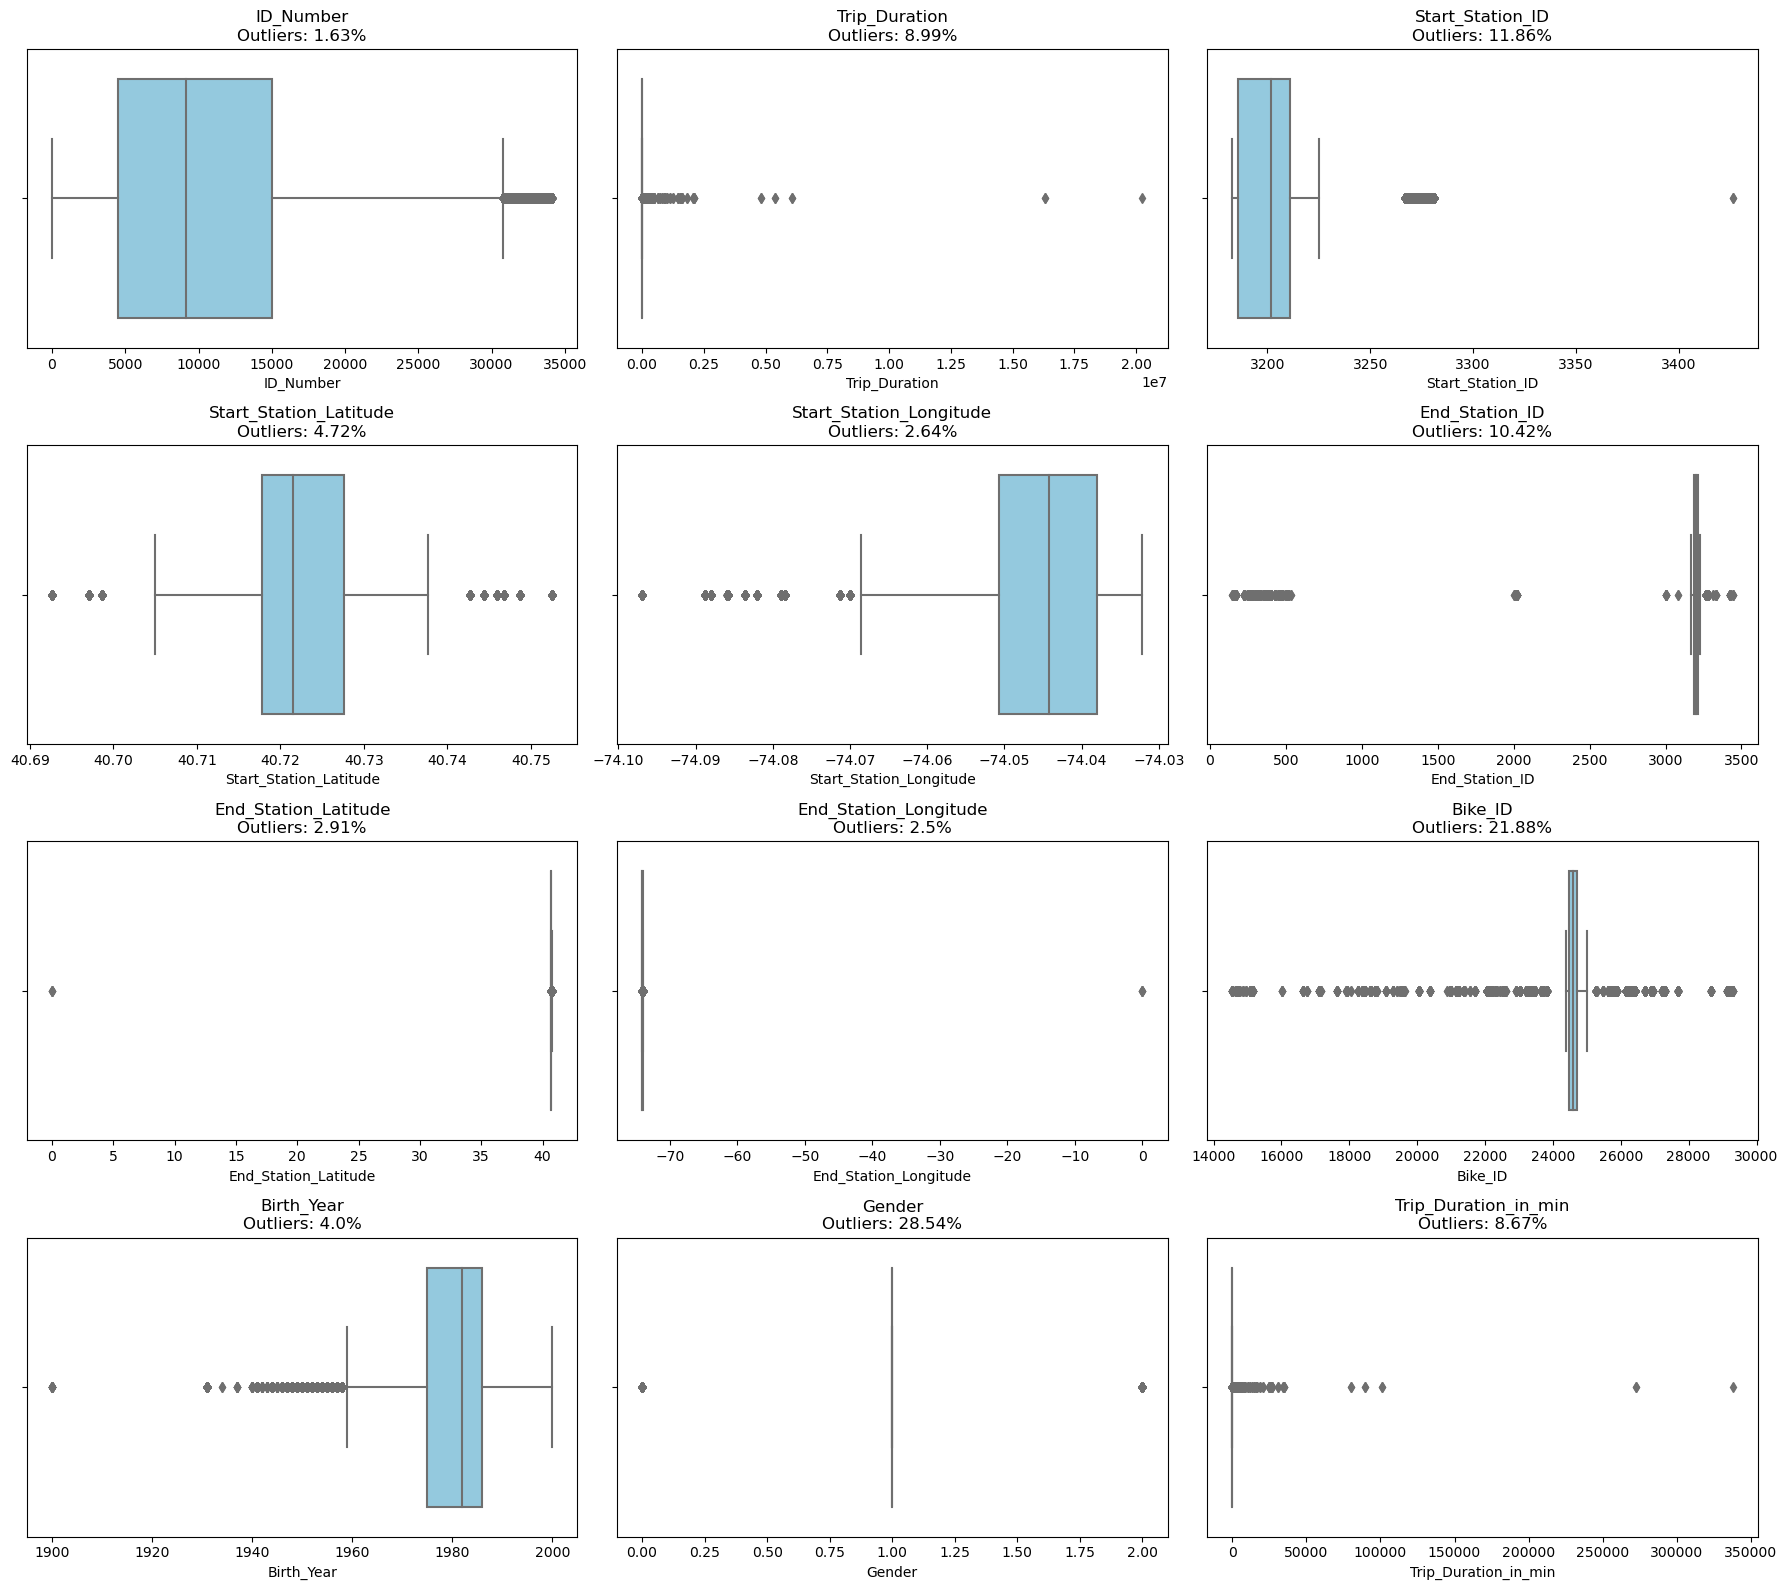

,column,low_bound,high_bound,outlier_count,outlier_%
10,Gender,1.00,1.00,209894,28.54
8,Bike_ID,24148.50,25048.50,160930,21.88
2,Start_Station_ID,3148.50,3248.50,87194,11.86
5,End_Station_ID,3148.50,3248.50,76606,10.42
1,Trip_Duration,-363.00,1261.00,66137,8.99
11,Trip_Duration_in_min,-6.50,21.50,63787,8.67
3,Start_Station_Latitude,40.70,40.74,34743,4.72
9,Birth_Year,1958.50,2002.50,29408,4.00
6,End_Station_Latitude,40.70,40.74,21436,2.91
4,Start_Station_Longitude,-74.07,-74.02,19438,2.64


In [13]:
detect_outliers(df, show_plots=True)

# Data Preparation

### Timestamp feature engineering

In [14]:
def split_start_stop_times(df, start_col='Start_Time', stop_col='Stop_Time'):
    
    df[start_col] = pd.to_datetime(df[start_col], errors='coerce')
    df[stop_col] = pd.to_datetime(df[stop_col], errors='coerce')
    
    df['start_year'] = df[start_col].dt.year
    df['start_month'] = df[start_col].dt.month_name()
    df['start_day'] = df[start_col].dt.day
    df['start_hour'] = df[start_col].dt.hour
    df['start_weekday'] = df[start_col].dt.day_name()
    
    df['stop_year'] = df[stop_col].dt.year
    df['stop_month'] = df[stop_col].dt.month_name()
    df['stop_day'] = df[stop_col].dt.day
    df['stop_hour'] = df[stop_col].dt.hour
    df['stop_weekday'] = df[stop_col].dt.day_name()
    
    return df

In [15]:
df = split_start_stop_times(df)

In [16]:
month_to_season = {
    'December' : 'Winter', 'January' : 'Winter', 'Feburary' : 'Winter',
    'March' : 'Spring', 'April' : 'Spring', 'May' : 'Spring',
    'June' : 'Summer', 'July' : 'Summer', 'August' : 'Summer',
    'September' : 'Fall', 'October' : 'Fall', 'November' : 'Fall'
}

df['start_season'] = df['start_month'].map(month_to_season)
df['stop_season'] = df['stop_month'].map(month_to_season)



In [17]:
trips_by_season = df.groupby('start_season').agg(
    total_trips=('Trip_Duration_in_min', 'count'),
    avg_duration=('Trip_Duration_in_min', 'mean')
).reset_index()

### Create new gender column with name of gender

In [18]:
def gender_names_map (df, column_name='Gender'):
    gender_map = {
        0: 'Unknown',
        1: 'Male',
        2: 'Female'
    }
    
    df['gender_name'] = df['Gender'].map(gender_map)
    return df



In [19]:
df = gender_names_map(df)

### Create new columns for age and weekend

In [20]:
df['age'] = df['start_year'] - df['Birth_Year']
df['is_weekend'] = df['start_weekday'].isin(['Saturday', 'Sunday'])

In [21]:
## Filtering out anyone over the age of 100
df = df[df['age']<=100]

In [22]:
## Creating bins to group ages for graphing
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

C:\Users\msche\AppData\Local\Temp\ipykernel_10716\3202266269.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)


In [23]:
## Make all column names lowercase
df.columns = df.columns.str.lower()

In [24]:
## Create columns for trip by hour, day of week, month, and year

trips_by_hour = df.groupby('start_hour')['trip_duration_in_min'].agg(
    total_trips='count',
    avg_duration='mean'
).reset_index()

trips_by_weekday = df.groupby('start_weekday')['trip_duration_in_min'].agg(
    total_trips='count',
    avg_duration='mean'
).reset_index()

trips_by_month = df.groupby(['start_year', 'start_month'])['trip_duration_in_min'].agg(
    total_trips='count',
    avg_duration='mean'
).reset_index()


In [25]:
## Create columns for demographics per trip

trips_by_gender = df.groupby('gender_name')['trip_duration_in_min'].agg(
    total_trips='count',
    avg_duration='mean'
).reset_index()

trips_by_age = df.groupby('age_group')['trip_duration_in_min'].agg(
    total_trips='count',
    avg_duration='mean'
).reset_index()

trips_by_usertype = df.groupby('user_type')['trip_duration_in_min'].agg(
    total_trips='count',
    avg_duration='mean'
).reset_index()

In [26]:
## Create columns for statistical analysis

top_starting_stations = df.groupby('start_station_name')['trip_duration_in_min'].agg(
    total_trips='count',
    avg_duration='mean'
).reset_index()

top_ending_station = df.groupby('end_station_name')['trip_duration_in_min'].agg(
    total_trips='count',
    avg_duration='mean'
).reset_index()

## Creating columns to calcuate the flow of bikes coming and leaving each sttaion
starts = df.groupby('start_station_name').size().rename('starts')
ends = df.groupby('end_station_name').size().rename('ends')

station_flow = pd.concat([starts, ends], axis=1).fillna(0)
station_flow['net_flow'] = station_flow['starts'] - station_flow['ends']
station_flow = station_flow.sort_values('net_flow', ascending=False)

# Exploratory Data Analysis

### Questions asked in the briefing
    1. When are Bikes used most?
    2. Where are the busiest start and end stations?
    3. How do Trip Durations vary by user type, gender, and age?
    4. Which stations experience consistent imbalances
    5. What seasonal patterns emerge?

### 1st question: When are Bikes used most?

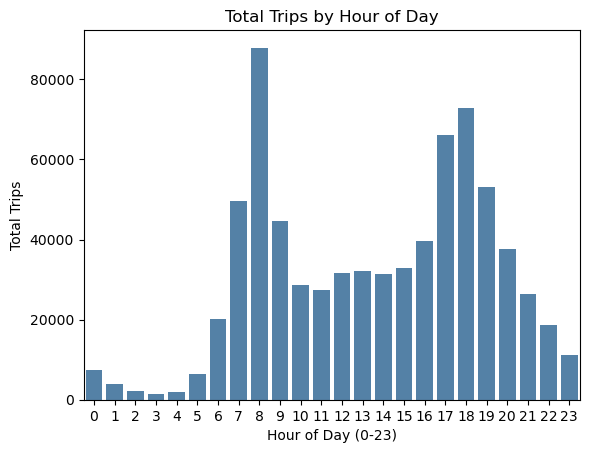

In [27]:
sns.barplot(data=trips_by_hour, 
            x='start_hour', 
            y='total_trips', 
            color='steelblue')
plt.title("Total Trips by Hour of Day")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Total Trips")
plt.show()



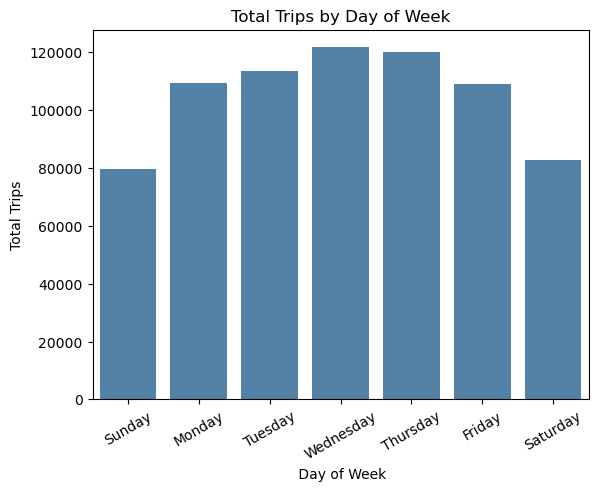

In [28]:
order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

sns.barplot(data=trips_by_weekday, 
            x='start_weekday', 
            y='total_trips',
            color='steelblue',
            order=order)
plt.title("Total Trips by Day of Week")
plt.xlabel(" Day of Week")
plt.ylabel("Total Trips")
plt.xticks(rotation=30)
plt.show()

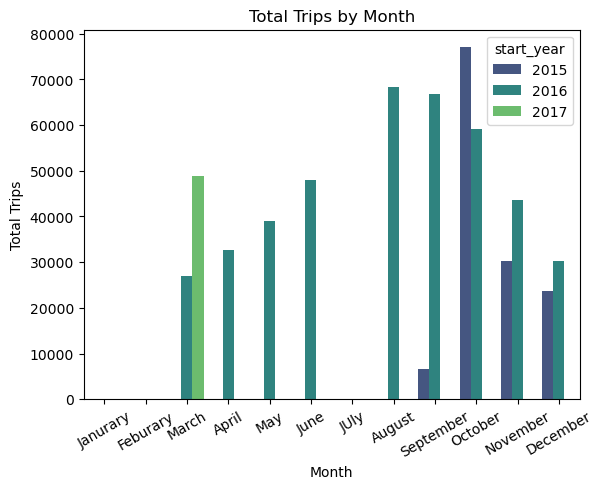

In [29]:
order = ['Janurary', 'Feburary', 'March', 'April', 'May', 'June', 'JUly', 'August', 'September', 'October', 'November', 'December']

sns.barplot(data=trips_by_month, 
            x='start_month', 
            y='total_trips', 
            hue='start_year',
            palette='viridis',
            order=order)
plt.title("Total Trips by Month")
plt.xlabel("Month")
plt.ylabel("Total Trips")
plt.xticks(rotation=30)
plt.show()

### Summary: When are Bikes used the most?
    1. Peak Times - between 7am to 9am and 5pm to 7pm
    2.Busiest Day - Wednesday
    3.Peak Month - August - October, August being busiest month


### Question 2: Where are the busiest Start and End Stations?

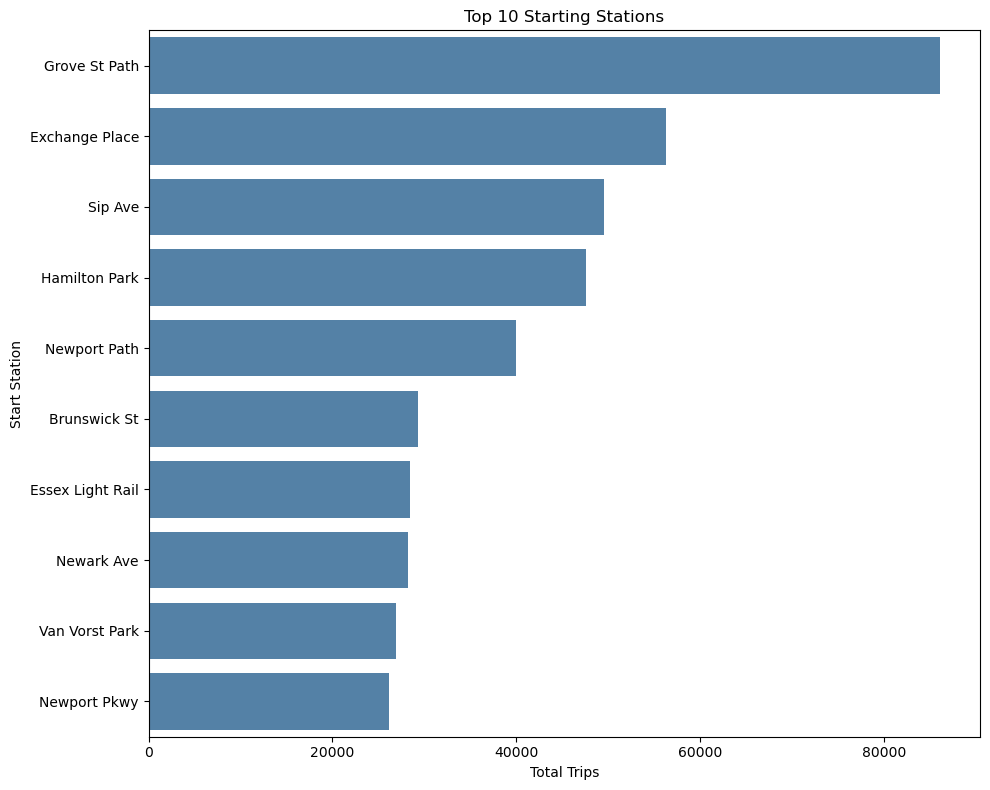

In [30]:
top_stations = top_starting_stations.nlargest(10, 'total_trips')
plt.figure(figsize=(10, 8))
sns.barplot(data=top_stations, 
            y='start_station_name', 
            x='total_trips', 
            color='steelblue')
plt.title("Top 10 Starting Stations")
plt.xlabel("Total Trips")
plt.ylabel("Start Station")
plt.tight_layout()
plt.show()


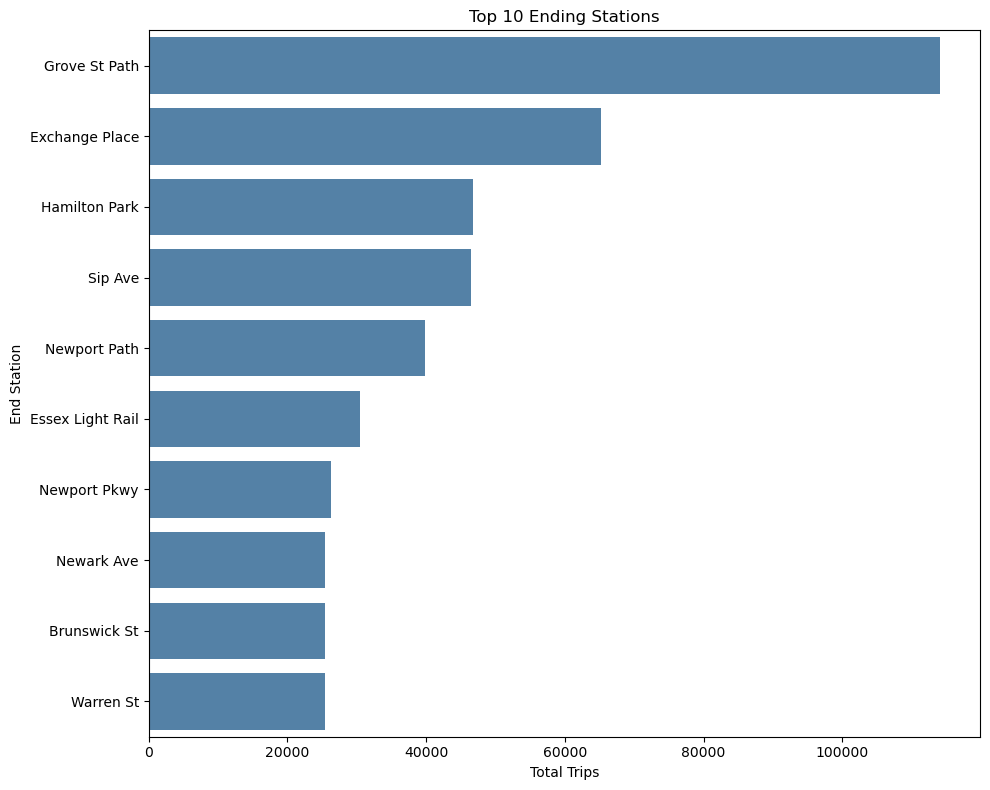

In [31]:
top_stations = top_ending_station.nlargest(10, 'total_trips')
plt.figure(figsize=(10, 8))
sns.barplot(data=top_stations, 
            y='end_station_name', 
            x='total_trips', 
            color='steelblue')
plt.title("Top 10 Ending Stations")
plt.xlabel("Total Trips")
plt.ylabel("End Station")
plt.tight_layout()
plt.show()

#### Summary:  Where are the busiest start and end stations?
    1. The top 5 starting and ending station appears to be Grove Street Path, exchange place, sip ave, Hamilton Park, and 
    Newport Path in this order
   

## Question 3: How do Trip Durations vary by user type, gender, and age?

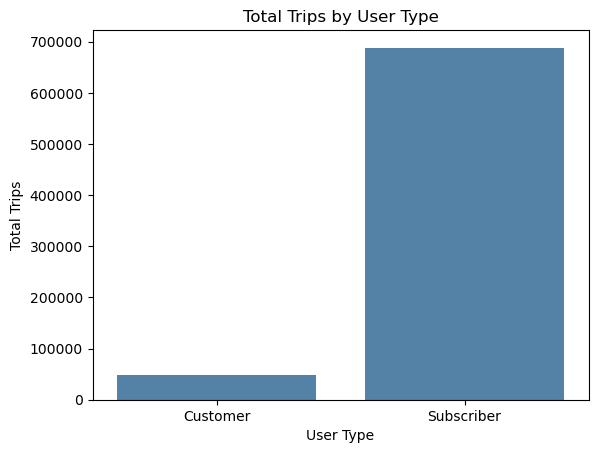

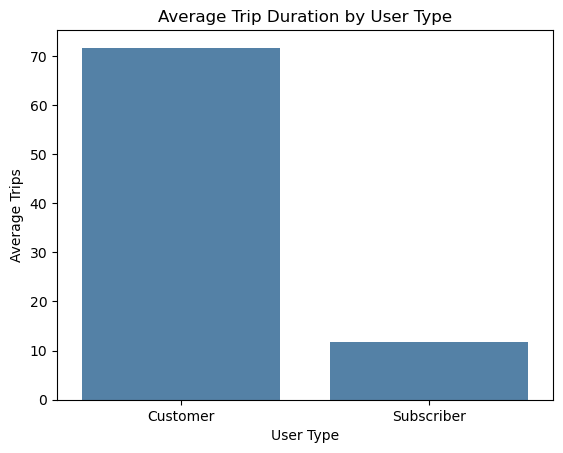

In [32]:
sns.barplot(data=trips_by_usertype, 
            x='user_type', 
            y='total_trips', 
            color='steelblue')
plt.title("Total Trips by User Type")
plt.xlabel("User Type")
plt.ylabel("Total Trips")
plt.show()

sns.barplot(data=trips_by_usertype, 
            x='user_type', 
            y='avg_duration', 
            color='steelblue')
plt.title("Average Trip Duration by User Type")
plt.xlabel("User Type")
plt.ylabel("Average Trips")
plt.show()



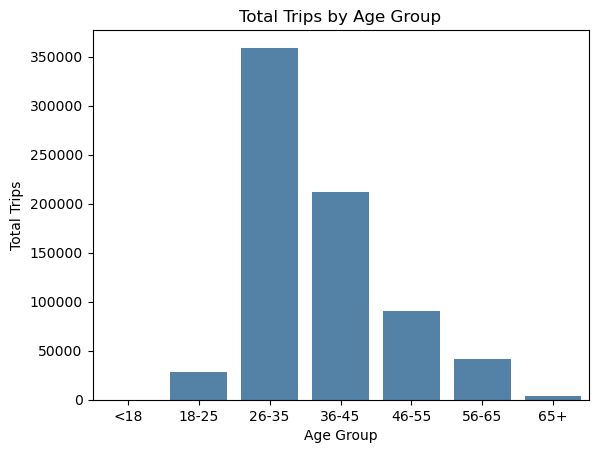

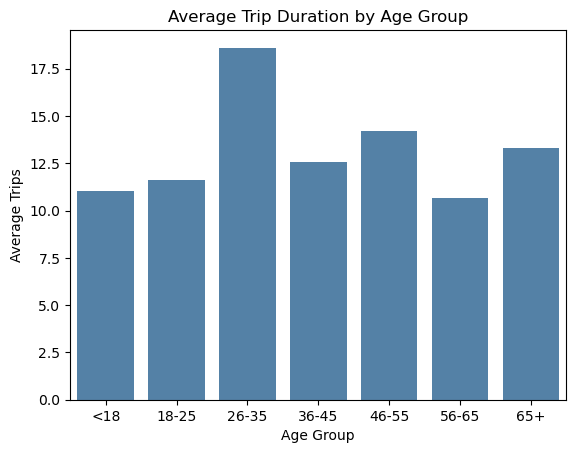

In [33]:
sns.barplot(data=trips_by_age, 
            x='age_group', 
            y='total_trips', 
            color='steelblue')
plt.title("Total Trips by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Trips")
plt.show()

sns.barplot(data=trips_by_age, 
            x='age_group', 
            y='avg_duration', 
            color='steelblue')
plt.title("Average Trip Duration by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Trips")
plt.show()


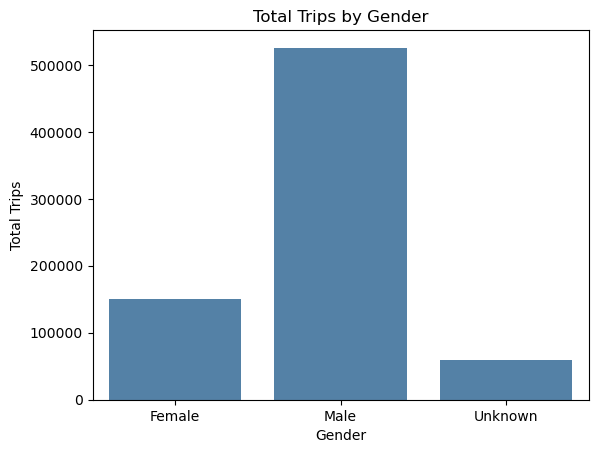

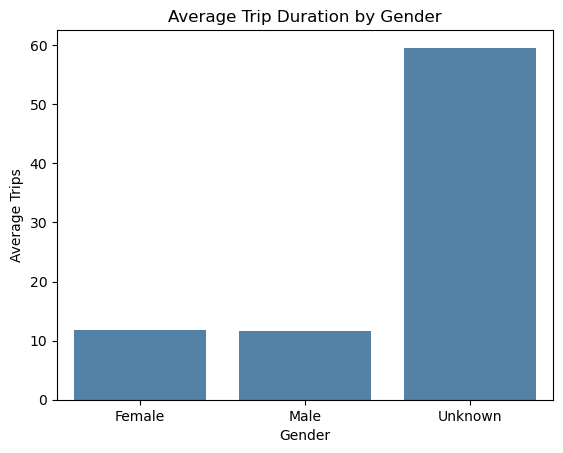

In [34]:
sns.barplot(data=trips_by_gender, 
            x='gender_name', 
            y='total_trips', 
            color='steelblue')
plt.title("Total Trips by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Trips")
plt.show()

sns.barplot(data=trips_by_gender, 
            x='gender_name', 
            y='avg_duration', 
            color='steelblue')
plt.title("Average Trip Duration by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Trips")
plt.show()


#### Summary:  How do Trip Durations vary by user type, gender, and age?
    1. User Types: Subscribers had the most total number of Trips but Customers had the longer Average trip
    2. Age: Ages between 26-35 had both the most total number of Trips taken and longest trip duration.
    3. Gender: Men had the most number of trips taken, and for average trip duration (excluding customers, the average trip
    duration was about the same for both men and female riders

## Question 4:  Which stations experience consistent imbalances?

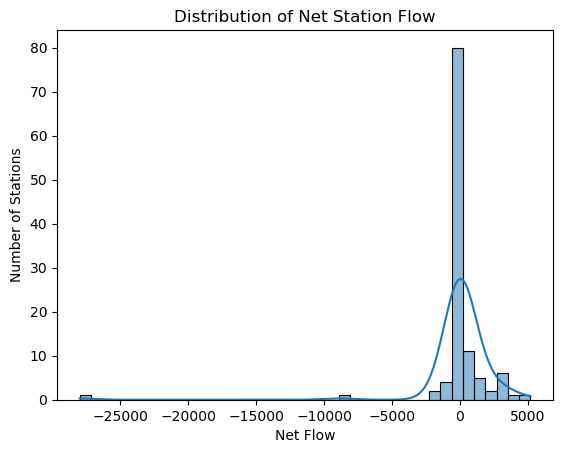

Stations with Most Positive Net Flow and need more bikes


,starts,ends,net_flow
Mcginley Square,20568.0,15374,5194.0
Brunswick St,29337.0,25484,3853.0
Van Vorst Park,26882.0,23572,3310.0
Jersey & 6Th St,10444.0,7188,3256.0
Sip Ave,49545.0,46541,3004.0
Hilltop,8078.0,5149,2929.0
Oakland Ave,12339.0,9456,2883.0
Newark Ave,28245.0,25490,2755.0
Baldwin At Montgomery,12723.0,10068,2655.0
Morris Canal,16400.0,14388,2012.0


Stations with Most Negative Net Flow and need bikes to be picked up from


,starts,ends,net_flow
Dey St,6190.0,6734,-544.0
City Hall,23976.0,24549,-573.0
Paulus Hook,23041.0,23691,-650.0
Jc Medical Center,14130.0,14834,-704.0
Union St,1024.0,1928,-904.0
Liberty Light Rail,17789.0,18986,-1197.0
Lincoln Park,9125.0,10654,-1529.0
Essex Light Rail,28459.0,30433,-1974.0
Exchange Place,56282.0,65154,-8872.0
Grove St Path,86155.0,114148,-27993.0


In [35]:
sns.histplot(data=station_flow,
           x='net_flow',
           bins=40,
           kde=True)
plt.title("Distribution of Net Station Flow")
plt.xlabel("Net Flow")
plt.ylabel("Number of Stations")
plt.show()

high_outflow = station_flow.head(10)
high_inflow = station_flow.tail(10)

print("Stations with Most Positive Net Flow and need more bikes")
display(high_outflow)

print("Stations with Most Negative Net Flow and need bikes to be picked up from")
display(high_inflow)

#### Summary: Which stations experience consistent imbalances?
    1. The station with the highest positive flow and need more bikes added is Mcginley Square, while the station with the highest negative flow and have an overflow of bikes parked is Grove St. Path

## Question 5:  What seasonal patterns emerge?

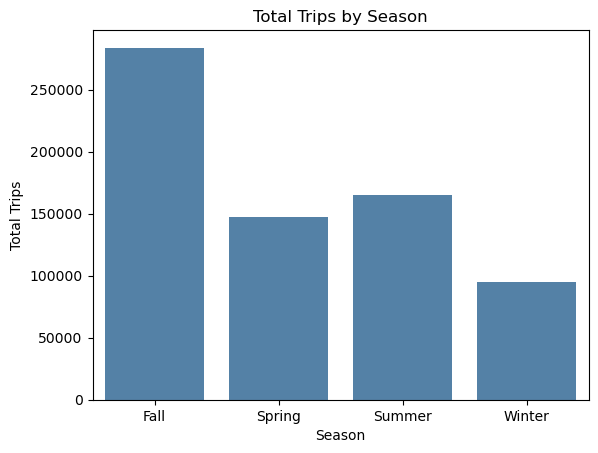

In [36]:
sns.barplot(data=trips_by_season, 
            x='start_season', 
            y='total_trips', 
            color='steelblue')
plt.title("Total Trips by Season")
plt.xlabel("Season")
plt.ylabel("Total Trips")
plt.show()

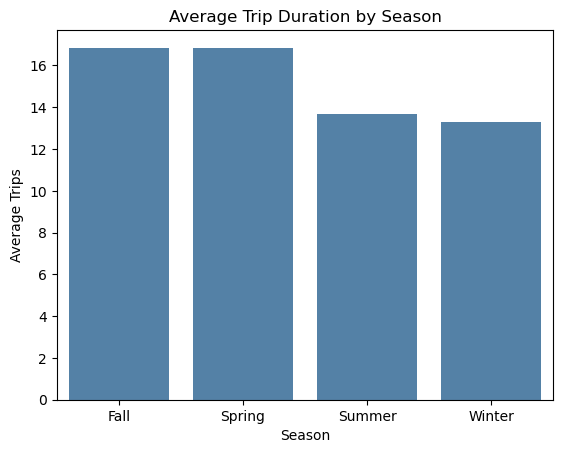

In [37]:
sns.barplot(data=trips_by_season, 
            x='start_season', 
            y='avg_duration', 
            color='steelblue')
plt.title("Average Trip Duration by Season")
plt.xlabel("Season")
plt.ylabel("Average Trips")
plt.show()


#### Summary:  What seasonal patterns emerge?
    1. Fall Had the highest total number of trips and average duration per trip (Cooler and more dry?)
    2. Summer had the 2nd highest number of trips but the average duration per trip was 3rd below Spring 
    (Heat being factor?)
    3. Spring had the 3rd highest number of trips, but the average duration per trip was 2nd higher than Summer 
    (Possible Rain?)
    4. Winter had both the lowest number of trips and lowest average duration trip (cold conditions?)

# Deeper Analysis
    1. Spatial Analysis
    2. User Behavior
    3. Time series analysis

## Spatial Analysis

#### Station Coverage Analysis
1. Where are the bike stations located?
2. Which neighborhoods have the highest density?
3. Are there noticeable coverage gaps?

In [38]:
## Preparing data for spatial analysis
stations = df[['start_station_name', 'start_station_latitude', 'start_station_longitude']].drop_duplicates()

print('Unique stations:', len(stations))

Unique stations: 51


In [39]:
## Create base map of NYC
nyc_map = folium.Map(location=[40.75, -73.97], zoom_start=12, tiles='CartoDB positron')

# Add clustered station markers
marker_cluster = MarkerCluster().add_to(nyc_map)

for _, row in stations.iterrows():
    folium.Marker(
        location=[row['start_station_latitude'], row['start_station_longitude']],
        popup=f"<b>{row['start_station_name']}</b>",
        icon=folium.Icon(color='blue', icon='bicycle', prefix='fa')
    ).add_to(marker_cluster)

# Save interactive map
nyc_map.save('station_coverage_map.html')

nyc_map


#### Summary:
The highest density is located just northeast of Jersey City, with the 2nd highest density being southwest of Jersey City.  If there is any gaps around Jersey city, it would be in Hoboken area

#### Station Flow Analysis
    1. Which stations are starting points? (High outflow)?
    2. Which Stations are ending points (high inflow)?
    3. Which are balanced?
    4. Are outflow/inflow-heavy stations geographically clustered?

In [40]:
# Total trips that START at each station
starts = df.groupby('start_station_name').size().reset_index(name='starts')

# Total trips that END at each station
ends = df.groupby('end_station_name').size().reset_index(name='ends')

# Merge both together
station_flow = pd.merge(
    starts,
    ends,
    left_on='start_station_name',
    right_on='end_station_name',
    how='outer'
)

# Combine into one station name column
station_flow['station_name'] = station_flow['start_station_name'].combine_first(station_flow['end_station_name'])

# Compute net flow (positive = more starts, negative = more ends)
station_flow['net_flow'] = station_flow['starts'] - station_flow['ends']

# Select columns neatly
station_flow = station_flow[['station_name','starts','ends','net_flow']]

# Attach coordinates
station_flow = station_flow.merge(
    df[['start_station_name','start_station_latitude','start_station_longitude']].drop_duplicates(),
    left_on='station_name',
    right_on='start_station_name',
    how='left'
)

# Clean up redundant column
station_flow = station_flow[['station_name','starts','ends','net_flow','start_station_latitude','start_station_longitude']]

station_flow.head()


,station_name,starts,ends,net_flow,start_station_latitude,start_station_longitude
0,5 Corners Library,7953.0,6542,1411.0,40.734961,-74.059503
1,Astor Place,1124.0,1146,-22.0,40.719282,-74.071262
2,Baldwin At Montgomery,12723.0,10068,2655.0,40.723659,-74.064194
3,Bayside Park,903.0,717,186.0,40.698651,-74.082080
4,Bethune Center,74.0,68,6.0,40.704958,-74.085931


In [41]:
flow_map = folium.Map(location=[40.75, -73.97], zoom_start=12, tiles='CartoDB positron')

def flow_color(v):
    if v > 0:
        return 'blue'
    if v < 0:
        return 'red'
    return 'grey'

for _, r in station_flow.dropna(subset=['start_station_latitude', 'start_station_longitude']).iterrows():
    popup = (f"<b>{r['station_name']}</b><br>"
            f"Starts: {int(r['starts'])}<br>"
            f"Ends: {int(r['ends'])}<br>"
            f"Net flow: {int(r['net_flow'])}")
    folium.CircleMarker(
        location=[r['start_station_latitude'], r['start_station_longitude']],
        radius=5 + (abs(r['net_flow']) / max(1, station_flow['net_flow'].abs().max())) * 8,
        color=flow_color(r['net_flow']),
        fill=True,
        fill_color=flow_color(r['net_flow']),
        fill_opacity=0.75,
        popup=popup
    ).add_to(flow_map)
    
flow_map.save("station_flow_map.html")
flow_map

#### Summary:
The station that has the largest net flow resultng in a large number of bikes being dropped off is located near the center of the city, by the hudson river, and close to a park.  Many of the stations within the center of Jersey City and further north are starting points which leads to a decrease of bikes being available for other riders to ride.

## User Behavior

## Questions
    1. Are there distinct groups of riders based on when they ride?
    2. Do riders cluster into commuter-like vs leisure-like based on duration and frequency?
    3. Are cluster geographically concentrated around certain stations or neighborhoods?
    4. Which rider clusters contribute most to station imbalances?

In [42]:
df.columns

Index(['id_number', 'trip_duration', 'start_time', 'stop_time',
       'start_station_id', 'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'birth_year', 'gender', 'trip_duration_in_min', 'start_year',
       'start_month', 'start_day', 'start_hour', 'start_weekday', 'stop_year',
       'stop_month', 'stop_day', 'stop_hour', 'stop_weekday', 'start_season',
       'stop_season', 'gender_name', 'age', 'is_weekend', 'age_group'],
      dtype='object')

## Question 1: Are there distinct groups of riders based on when they ride?
Features to use: user_type, is_weekend, start_season, start_month, start_weekday, trip_duration_in_min, hour, gender, age

### Encoding process

In [43]:
month_map = {
    'January': 1, 'February': 2, 'March': 3,
    'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9,
    'October': 10, 'November': 11, 'December': 12
}

df['month_encoded'] = df['start_month'].map(month_map)

day_map = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}

df['weekday_encoded'] = df['start_weekday'].map(day_map)


season_map = {
    'Winter': 0,
    'Spring': 1,
    'Summer': 2,
    'Fall': 3
}

df['season_encoded'] = df['start_season'].map(season_map)

df['user_type_encoded'] = df['user_type'].map({
    'Subscriber': 0,
    'Customer': 1
})

df['is_weekend_encoded'] = df['is_weekend'].astype(int)






C:\Users\msche\AppData\Local\Temp\ipykernel_10716\1722556824.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_encoded'] = df['start_month'].map(month_map)
C:\Users\msche\AppData\Local\Temp\ipykernel_10716\1722556824.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['weekday_encoded'] = df['start_weekday'].map(day_map)
C:\Users\msche\AppData\Local\Temp\ipykernel_10716\1722556824.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

In [44]:
## Clustering features
cluster_features = [
    'trip_duration_in_min',
    'start_hour',
    'month_encoded',
    'weekday_encoded',
    'season_encoded',
    'user_type_encoded',
    'is_weekend_encoded',
    'age',
    'gender',
]

x = df[cluster_features].dropna().copy()

x.head()

,trip_duration_in_min,start_hour,month_encoded,weekday_encoded,season_encoded,user_type_encoded,is_weekend_encoded,age,gender
0,6,0,10,3,3.0,0,0,55,1
1,12,0,10,3,3.0,0,0,55,1
2,45,0,10,3,3.0,0,0,32,1
3,5,0,10,3,3.0,0,0,40,1
4,9,0,10,3,3.0,1,0,31,0


In [45]:
x.describe()

,trip_duration_in_min,start_hour,month_encoded,weekday_encoded,season_encoded,user_type_encoded,is_weekend_encoded,age,gender
count,690931.000000,690931.000000,690931.000000,690931.000000,690931.000000,690931.000000,690931.000000,690931.000000,690931.000000
mean,15.595569,13.612287,7.603719,2.783628,1.922934,0.066273,0.220309,36.342124,1.122646
std,691.062312,5.231551,3.193641,1.904949,1.080003,0.248759,0.414455,9.342952,0.522127
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,16.000000,0.000000
25%,4.000000,9.000000,5.000000,1.000000,1.000000,0.000000,0.000000,30.000000,1.000000
50%,6.000000,14.000000,8.000000,3.000000,2.000000,0.000000,0.000000,34.000000,1.000000
75%,11.000000,18.000000,10.000000,4.000000,3.000000,0.000000,0.000000,41.000000,1.000000
max,337670.000000,23.000000,12.000000,6.000000,3.000000,1.000000,1.000000,86.000000,2.000000


### Scaling and determining number of clusters

In [46]:
## Scaling the data to prepare for KMeans
scaler = StandardScaler()
x_scales = scaler.fit_transform(x)

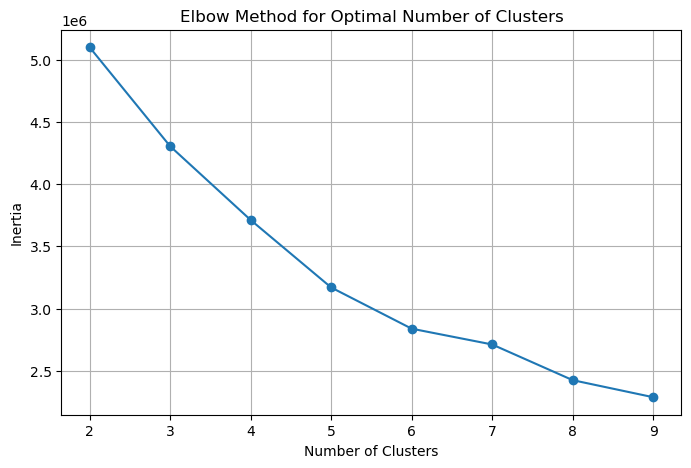

In [47]:
## Elbow test to determine the number of clusters
inertia = []

K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(x_scales)
    inertia.append(km.inertia_)
    
plt.figure(figsize=(8,5))
plt.plot(K, inertia, '-o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(True)
plt.show()

### Creating the clusters

In [48]:
## Clustering the data
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(x_scales)

cluster_series = pd.Series(cluster_labels, index=x.index, name='cluster')

df = df.join(cluster_series)

df['cluster'].value_counts()

cluster
1.0    515959
0.0    129178
2.0     45794
Name: count, dtype: int64

In [49]:
## Cluster centers

# Scaled centers
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=x.columns
)

#unscaled centers
centers_unscaled = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=x.columns
)

cluster_centers
centers_unscaled

,trip_duration_in_min,start_hour,month_encoded,weekday_encoded,season_encoded,user_type_encoded,is_weekend_encoded,age,gender
0,12.880661,13.806987,7.698803,5.482884,1.971481,-8.548717e-15,1.000000e+00,35.981049,1.223072
1,9.854849,13.496551,7.560924,2.020428,1.893276,3.955170e-14,-1.159906e-13,36.844063,1.196880
2,87.934358,14.367057,7.817662,3.768376,2.120147,9.999127e-01,5.031227e-01,31.705333,0.002970


In [50]:
cluster_summary = df.groupby('cluster')[x.columns].mean()
cluster_summary

,trip_duration_in_min,start_hour,month_encoded,weekday_encoded,season_encoded,user_type_encoded,is_weekend_encoded,age,gender
cluster,,,,,,,,,
0.0,12.880661,13.806987,7.698803,5.482884,1.971481,0.000000,1.000000,35.981049,1.223072
1.0,9.854849,13.496551,7.560924,2.020428,1.893276,0.000000,0.000000,36.844063,1.196880
2.0,87.934358,14.367057,7.817662,3.768376,2.120147,0.999913,0.503123,31.705333,0.002970


### Visualization of Clusters

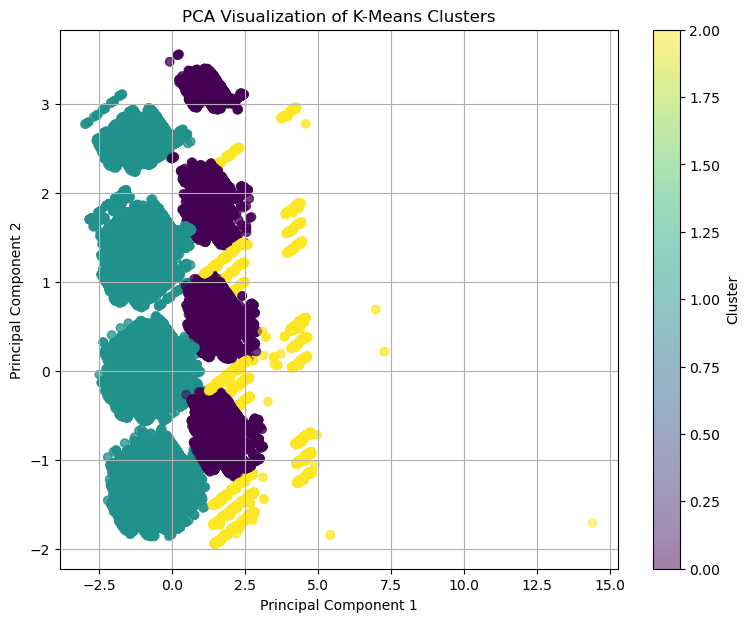

In [51]:
## Visualize the clusters
x_used = x_scales

pca = PCA(n_components=2)
components = pca.fit_transform(x_used)

pca_df = pd.DataFrame(components, columns=['PC1', 'PC2'], index=x.index)
pca_df['cluster'] = df.loc[x.index, 'cluster']

plt.figure(figsize=(9,7))
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster'],
    cmap='viridis',
    alpha=0.5
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of K-Means Clusters")
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

In [52]:
## PCA components
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=x.columns
)

loadings

,PC1,PC2
trip_duration_in_min,0.020745,-0.001824
start_hour,0.052457,0.010273
month_encoded,0.077227,-0.692466
weekday_encoded,0.554057,0.149913
season_encoded,0.100473,-0.690181
user_type_encoded,0.438670,-0.036238
is_weekend_encoded,0.574145,0.122390
age,-0.141691,0.071228
gender,-0.362808,0.013838


In [53]:
df['cluster'].value_counts()

cluster
1.0    515959
0.0    129178
2.0     45794
Name: count, dtype: int64

In [54]:
cluster_labels = {
    0: "Purple Cluster",
    1: "Green Cluster",
    2: "Yellow Cluster"
}

df['cluster_labels'] = df['cluster'].map(cluster_labels)

### Summary: Initial Interpretation of clusters
    cluster 0 (Purple) = Main Weekday Riders
    Cluster 1 (Green) = Evening/Mixed Commuters
    Cluster 2 (Yellow) = Weekend Casual Riders
    
 *** These labels may change after further analysis of clusters ***
    

### Analysis of clusters

In [55]:
cluster_summary = df.groupby('cluster')[x.columns].mean().round(2)
cluster_summary

,trip_duration_in_min,start_hour,month_encoded,weekday_encoded,season_encoded,user_type_encoded,is_weekend_encoded,age,gender
cluster,,,,,,,,,
0.0,12.88,13.81,7.70,5.48,1.97,0.0,1.0,35.98,1.22
1.0,9.85,13.50,7.56,2.02,1.89,0.0,0.0,36.84,1.20
2.0,87.93,14.37,7.82,3.77,2.12,1.0,0.5,31.71,0.00


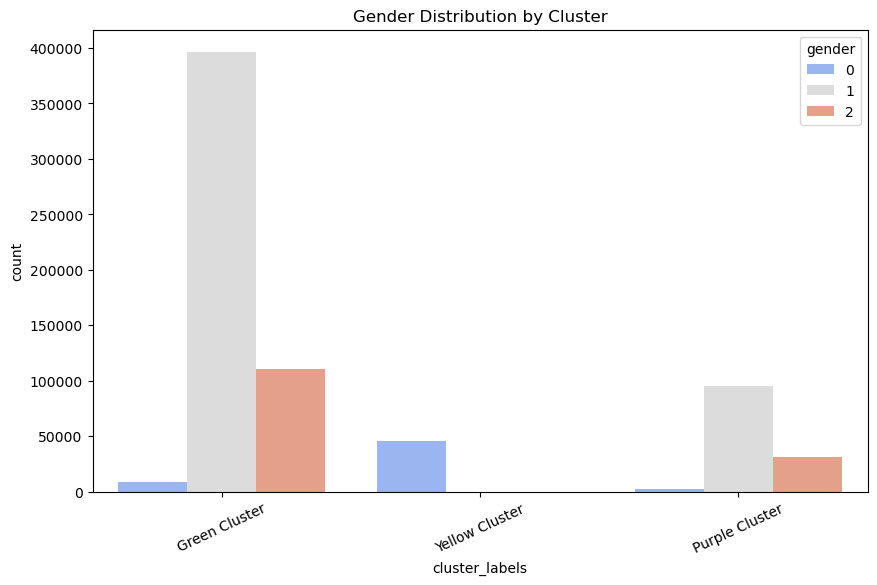

In [56]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x='cluster_labels',
    hue='gender',
    palette='coolwarm'
)
plt.title("Gender Distribution by Cluster")
plt.xticks(rotation=25)
plt.show()

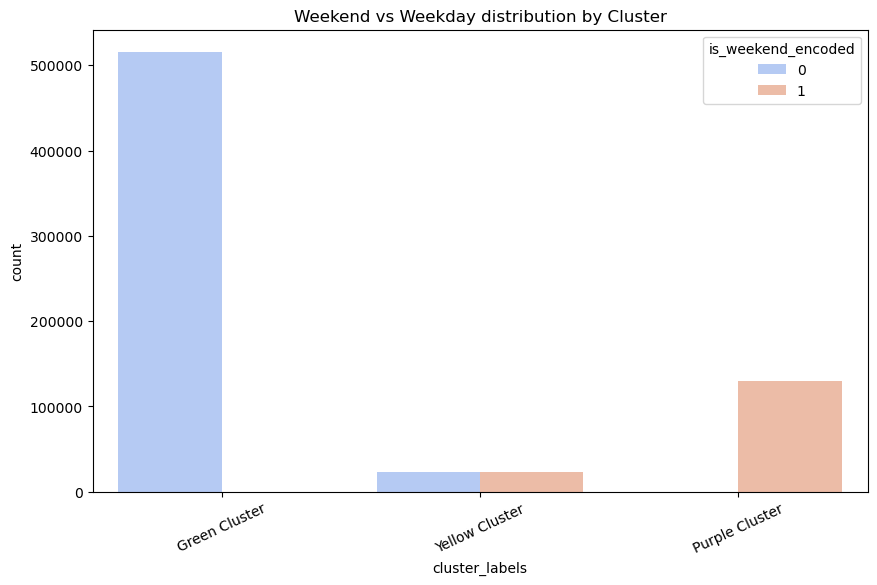

In [57]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x='cluster_labels',
    hue='is_weekend_encoded',
    palette='coolwarm'
)
plt.title("Weekend vs Weekday distribution by Cluster")
plt.xticks(rotation=25)
plt.show()

 **** Noting that cluster 0 is mainly weekend riders **** <br>
 **** Noting Cluster 1 is Weekday Riders ****

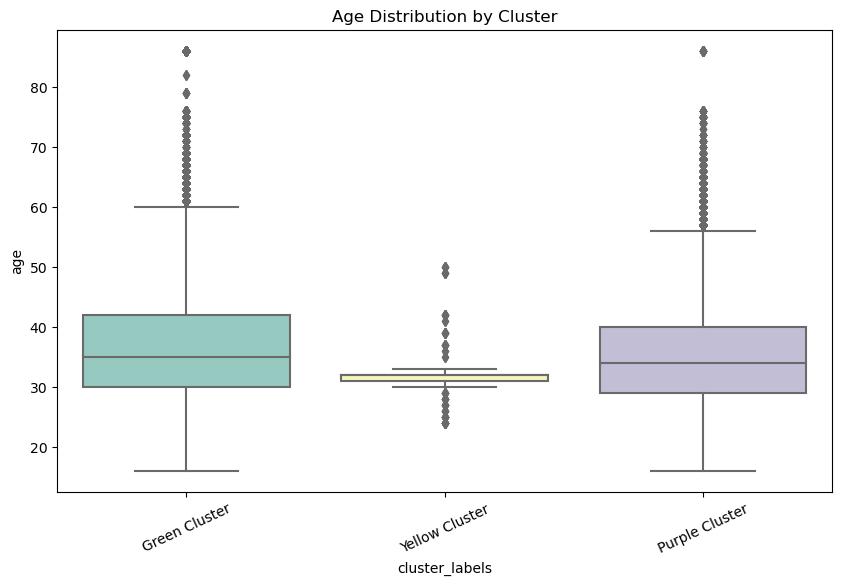

In [58]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='cluster_labels',
    y='age',
    palette='Set3'
)
plt.title("Age Distribution by Cluster")
plt.xticks(rotation=25)
plt.show()

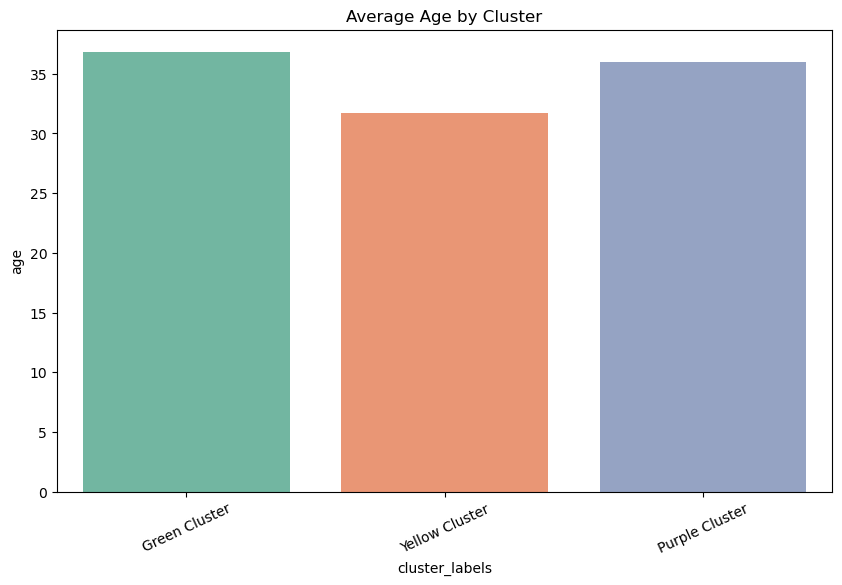

In [59]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='cluster_labels',
    y='age',
    estimator='mean',
    errorbar=None,
    palette='Set2'
)
plt.title("Average Age by Cluster")
plt.xticks(rotation=25)
plt.show()

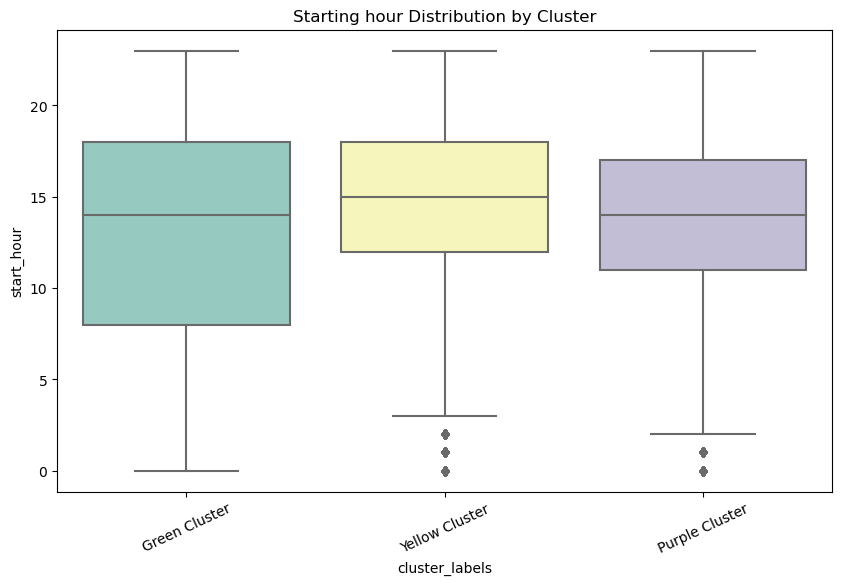

In [60]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='cluster_labels',
    y='start_hour',
    palette='Set3'
)
plt.title("Starting hour Distribution by Cluster")
plt.xticks(rotation=25)
plt.show()

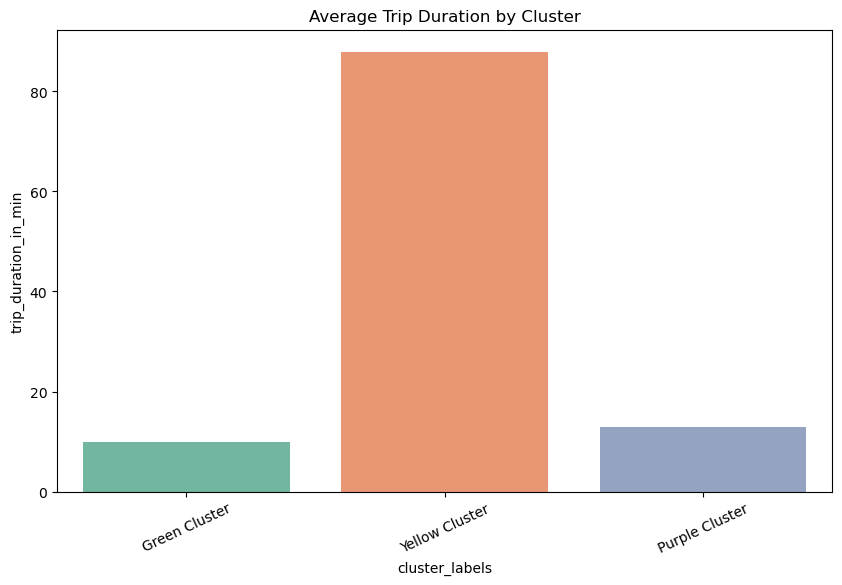

In [61]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='cluster_labels',
    y='trip_duration_in_min',
    estimator='mean',
    errorbar=None,
    palette='Set2'
)
plt.title("Average Trip Duration by Cluster")
plt.xticks(rotation=25)
plt.show()

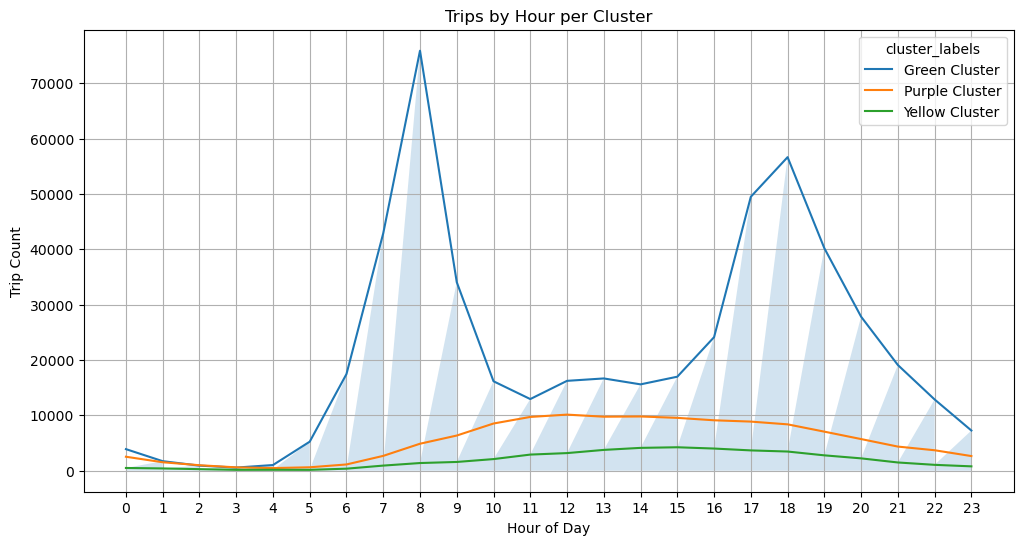

In [62]:
hour_cluster_counts = (
    df.loc[x.index]
      .groupby(['start_hour', 'cluster_labels'])
      .size()
      .reset_index(name='count')
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=hour_cluster_counts,
    x='start_hour',
    y='count',
    hue='cluster_labels',
    estimator=None
)

plt.fill_between(
    hour_cluster_counts['start_hour'],
    hour_cluster_counts['count'],
    alpha=0.2
)

plt.title("Trips by Hour per Cluster")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Count")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()


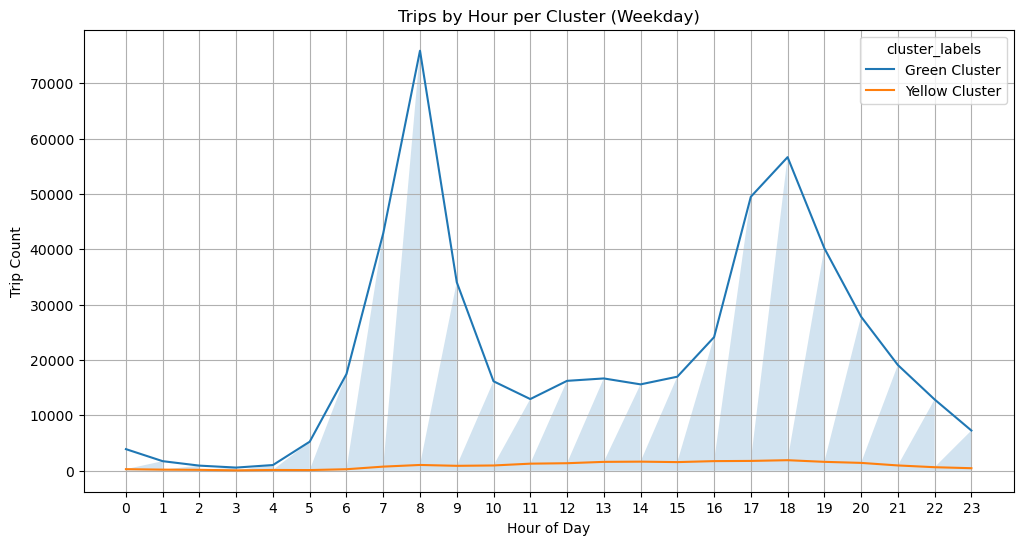

In [63]:
hour_cluster_counts = (
    df.loc[x.index]
        .query("is_weekend_encoded == 0")
        .groupby(['start_hour', 'cluster_labels'])
        .size()
        .reset_index(name='count')
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=hour_cluster_counts,
    x='start_hour',
    y='count',
    hue='cluster_labels',
    estimator=None
)

plt.fill_between(
    hour_cluster_counts['start_hour'],
    hour_cluster_counts['count'],
    alpha=0.2
)

plt.title("Trips by Hour per Cluster (Weekday)")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Count")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

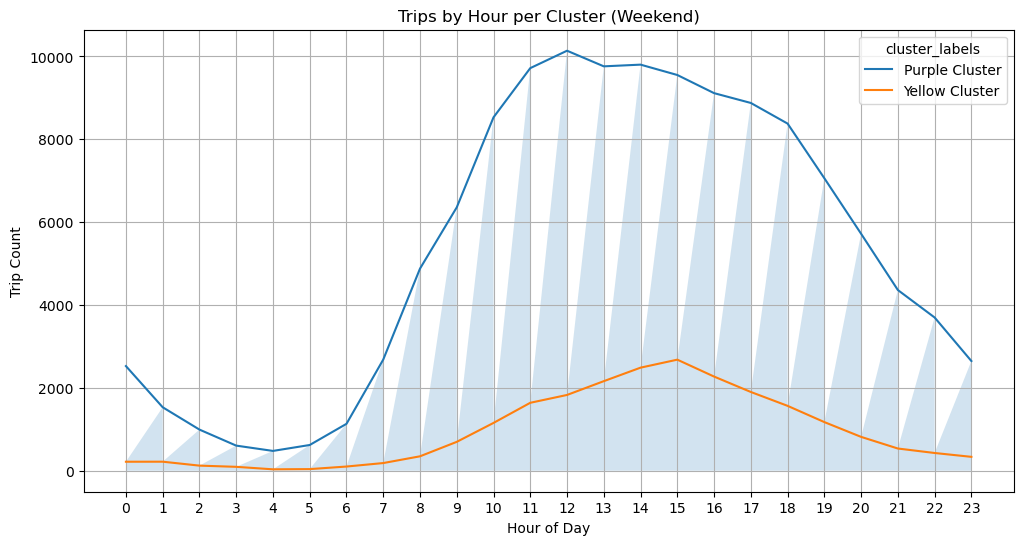

In [64]:
hour_cluster_counts = (
    df.loc[x.index]
        .query("is_weekend_encoded == 1")
        .groupby(['start_hour', 'cluster_labels'])
        .size()
        .reset_index(name='count')
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=hour_cluster_counts,
    x='start_hour',
    y='count',
    hue='cluster_labels',
    estimator=None
)

plt.fill_between(
    hour_cluster_counts['start_hour'],
    hour_cluster_counts['count'],
    alpha=0.2
)

plt.title("Trips by Hour per Cluster (Weekend)")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Count")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

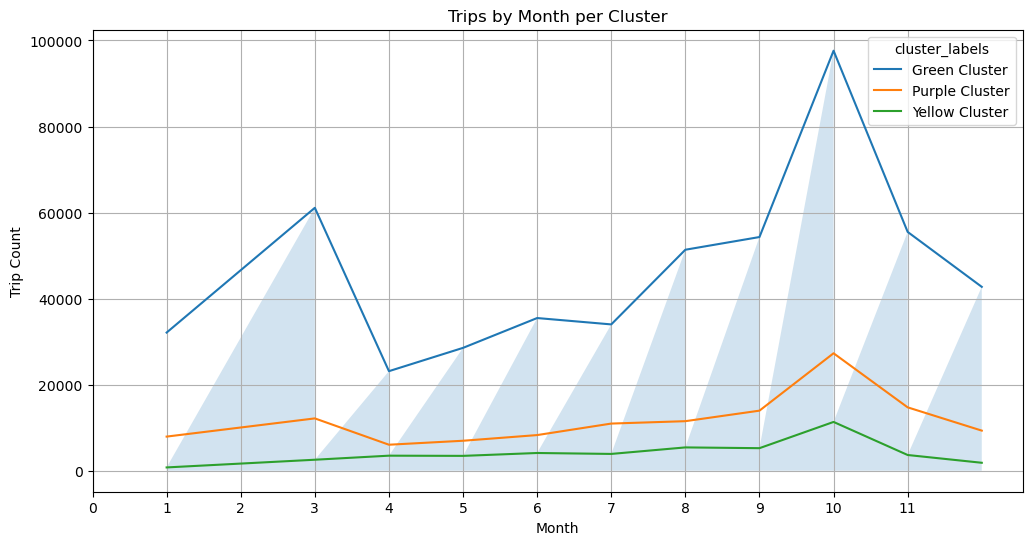

In [65]:
month_cluster_counts = (
    df.loc[x.index]
      .groupby(['month_encoded', 'cluster_labels'])
      .size()
      .reset_index(name='count')
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=month_cluster_counts,
    x='month_encoded',
    y='count',
    hue='cluster_labels',
    estimator=None
)

plt.fill_between(
    month_cluster_counts['month_encoded'],
    month_cluster_counts['count'],
    alpha=0.2
)

plt.title("Trips by Month per Cluster")
plt.xlabel("Month")
plt.ylabel("Trip Count")
plt.xticks(range(0,12))
plt.grid(True)
plt.show()

### Cluster Analysis Summary

cluster 0 (Purple) = Weekend Local Riders <br>
Cluster 1 (Green) = Core Work Commuters <br>
Cluster 2 (Yellow) = Recreational/Casual (Tourists) <br>

## Cluster Analysis - Spatial

In [66]:
lat_station = 'start_station_latitude'
lon_station = 'start_station_longitude'
name_station = 'start_station_name'

def make_cluster_station_map(df, cluster_name, color='green'):
    # filter to this cluster
    sub = df[df['cluster_labels'] == cluster_name].copy()
        
    # Aggregate station level
    station_counts = (
        sub.groupby([name_station, lat_station, lon_station])
            .size()
            .reset_index(name='trip_count')
    )
    
    # Centering the map
    m = folium.Map(location=[40.721, -74.047], zoom_start=13)
    
    mc = MarkerCluster().add_to(m)
    
    ## Scaling radius by trip volume
    max_count = station_counts['trip_count'].max()
    for _, row in station_counts.iterrows():
        radius = 3 + 7 * np.sqrt(row['trip_count'] / max_count)
        
        tooltip = f"{row[name_station]}<br>Trips: {row['trip_count']}"
        
        folium.CircleMarker(
            location=[row[lat_station], row[lon_station]],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.6,
            tooltip=tooltip
        ).add_to(mc)
    title_html = f'''
        <h4 style="position: fixed; top: 10px; left: 50px; z-index:9999;
        background-color: white; padding: 5px; border-radius: 4px;">
        {cluster_name} - Start Station Hotspots</h4>
    </h4>
    '''
    
    m.get_root().html.add_child(folium.Element(title_html))
    
    return m

In [67]:
map_commuters = make_cluster_station_map(
    df,
    cluster_name='Green Cluster',
    color='green'
)
map_commuters

In [68]:
map_commuters = make_cluster_station_map(
    df,
    cluster_name='Purple Cluster',
    color='purple'
)
map_commuters

In [69]:
map_commuters = make_cluster_station_map(
    df,
    cluster_name='Yellow Cluster',
    color='red'
)
map_commuters

## Exporting dataset to excel

In [70]:
cluster_labels = {
    0: "Weekend Local Riders",
    1: "Core Work Commuters",
    2: "Recreational/Casual (Tourists)"
}

df['cluster_labels'] = df['cluster'].map(cluster_labels)

In [71]:
df.to_csv("Jersey_City_bikeshare.csv", index=False)

## Key findings

1. Ridership peaks during commuter hours (7-9am and 5-7pm), indicating strong work-related usage patterns.

2. A small group of stations accounts for a disproportionately high number of trip starts and trip ends, revealing major transportation hubs within Jersey City.

3. Subscribers generate the majority of rides, suggesting the system relies heavily on repeat users rather than occasional riders.

4. Several stations experience persistent bike-flow imbalances, creating potential operational challenges for bike redistribution.

5. Fall produces both the highest trip volume and the longest average trip durations, highlighting seasonal demand patterns.

6. Cluster analysis identified three distinct rider groups:
    - Weekend Local Riders
    - Core Work Communters
    - Recreational Riders
    
## Business Recommendations

1. Support Commuter Demand
    
- Biker demand peaks around commuter hours, so the operators of the bikeshare program should priortize making sure that bikes are always available during the morning and evening rush hours.

2. Expanding High-Performing Stations

- Since there are a small number of stations that account for a high number of trip starts and trip ends, these stations can benefit with an increase in bike docking capacity to help ease potential traffic congestion.

3. Improving Bike Destribution

- There are stations that showed either a shortage of bikes or a surplus, which should be monitored and serviced more frequently to improve availability.

4. Seasonal Planning

- Additional bikes and maintenance should be allocated during the fall months when demand is the highest.

5. Rider-Specific Marketing

- Different riders may respond to different promotions, allowing the bikeshare program to target commuters, recreational riders, and weekend users more effectively and potentially lead to new subscribers.